In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q pandas numpy matplotlib ar_wordcloud arabic-reshaper python-bidi

In [ ]:
from __future__ import annotations
import pandas as pd
import numpy as np
import regex as re
import matplotlib.pyplot as plt
from collections import Counter
from ar_wordcloud import ArabicWordCloud
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Arabic shaping helper
def ar_shape(s):
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        if not isinstance(s, str): return s
        return get_display(arabic_reshaper.reshape(s))
    except Exception:
        return s

In [ ]:
# --- Load data ---
file_path = "/content/drive/MyDrive/MSIS-822-Project/v2/data/02_long-clean_phase_2/arabic_generated_abstracts_long_clean_v2.csv"
df = pd.read_csv(file_path)

In [ ]:
# --- Labels ---
label_map = {0: 'Human', 1: 'AI'}
df['label_name'] = df['label'].map(label_map)

## Statistical Analysis: Average Words per Document

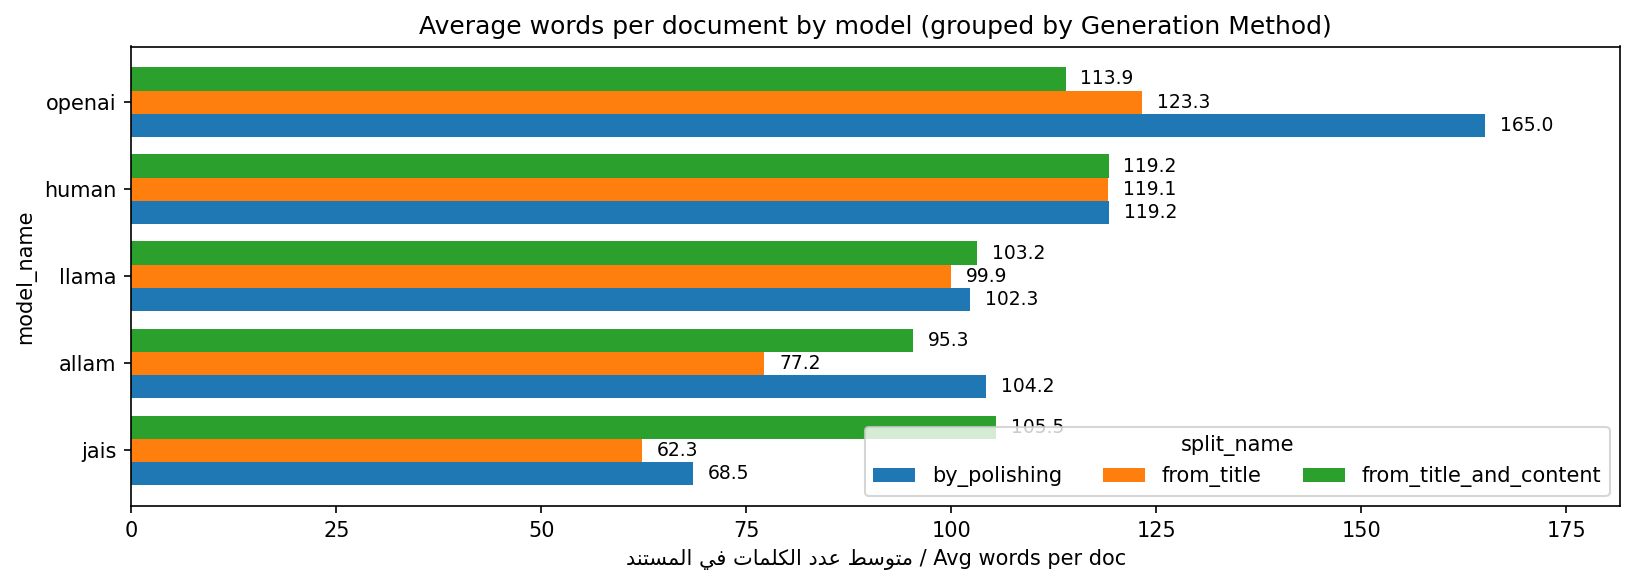

In [ ]:
def avg_words_by_split_model(df, text_col="text"):
    return (
        df.assign(
            _text=df[text_col].fillna("").astype(str).str.strip(),
            word_count=lambda x: x["_text"].str.split().str.len()
        )
        .groupby(["split_name", "model_name"], as_index=False)["word_count"]
        .mean()
        .rename(columns={"word_count": f"avg_{text_col}"})
    )

avg_sm = avg_words_by_split_model(df, text_col="text")

# 2) Pivot to models × splits
pivot = avg_sm.pivot(index="model_name", columns="split_name", values="avg_text").fillna(0)

# Optional: order models by overall average for readability
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

models = pivot.index.tolist()
splits  = pivot.columns.tolist()

# 3) Plot: one figure, grouped horizontal bars
y = np.arange(len(models))
n = len(splits)
h = 0.8 / max(n, 1)     # total band height ~0.8, split evenly
offsets = (np.arange(n) - (n - 1) / 2) * h

plt.figure(figsize=(11, max(4, 0.45 * len(models))), dpi=150)

bars_by_split = []
xmax = float(pivot.to_numpy().max()) * 1.10 if pivot.size else 1.0

for idx, split in enumerate(splits):
    vals = pivot[split].to_numpy()
    bar = plt.barh(y + offsets[idx], vals, height=h, label=split)
    bars_by_split.append((bar, vals))

# shared x-limit + annotations
plt.xlim(0, xmax)

for bar, vals in bars_by_split:
    for b, v in zip(bar, vals):
        ymid = b.get_y() + b.get_height() / 2
        plt.text(v + xmax * 0.01, ymid, f"{v:.1f}", va="center", fontsize=9)

plt.yticks(y, models)
plt.xlabel(ar_shape("متوسط عدد الكلمات في المستند") + " / Avg words per doc")
plt.ylabel("model_name")
plt.title("Average words per document by model (grouped by Generation Method)")
plt.legend(title="split_name", loc="lower right", ncols=min(len(splits), 3))
plt.tight_layout()
plt.show()

## Statistical Analysis: Word, Sentence, and Vocabulary Metrics


In [ ]:
df = df.copy()
df['text_raw'] = df['text'].astype(str)

# --- Minimal normalization that KEEPS punctuation ---
_AR_DIACRITICS = re.compile(r'[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]')
_TATWEEL = "\u0640"

def normalize_keep_punct(s: str) -> str:
    # unify alef variants; tame hamza carriers; remove alef maqsūra/tatweel; strip diacritics
    s = re.sub(r'[ٱآأإ]', 'ا', s)
    s = s.replace('ؤ', 'و').replace('ئ', 'ي').replace('ى', 'ي').replace(_TATWEEL, '')
    s = _AR_DIACRITICS.sub('', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df['text_norm_keep_punct'] = df['text_raw'].apply(normalize_keep_punct)

# --- Splitters ---
# Sentence boundaries: DO NOT split on comma '،' or semicolon '؛'
AR_SENT_SPLIT = re.compile(r'[\.!\?؟…]+')
WS_SPLIT = re.compile(r'\s+')

def ar_sentences(text: str):
    return [s.strip() for s in AR_SENT_SPLIT.split(text) if s.strip()]

def ar_tokens_whitespace(text: str):
    return [t for t in WS_SPLIT.split(text) if t]

#--- Token filters for lexical stats (words only) ---
AR_WORD = re.compile(r'^\p{Arabic}[\p{Arabic}\p{Nd}_]*$')  # Arabic-first, then Arabic/ND/underscore
def word_only(tokens):
    return [t for t in tokens if AR_WORD.match(t)]

def type_token_ratio(tokens):
    return (len(set(tokens)) / len(tokens)) if tokens else 0.0


## Lexical Analysis

In [ ]:
# --- Function words & punctuation ---
AR_FUNCTION_WORDS = {
    # conjunctions
    'و','أو','ثم','لكن','بل','حتى','ف','كما','لأن','حيث','إذ','إلا',
    # prepositions
    'في','على','من','إلى','عن','ب','ك','ل','مع','بين','عند','قبل','بعد','تحت','فوق',
    # particles / modals / copulas (common)
    'قد','لم','لن','إن','أن','كان','ليس','ما','لا','هذا','هذه','ذلك','تلك','هناك','هنا'
}
# Proclitic set (very light heuristic, no morphological segmentation)
PROCLITIC_CHARS = 'وفبكلل'  # و ف ب ك ل ل (note doubled ل to catch definite article combos)
DEF_ARTICLE = 'ال'

AR_PUNCT_SET = set(list('،؛؟.!…:"()[]{}-—_,'))

def count_punct_chars(text: str):
    return sum(ch in AR_PUNCT_SET for ch in text)

def count_function_words(tokens):
    """Count standalone function words + naive clitic occurrences."""
    # standalone
    standalone = sum(1 for t in tokens if t in AR_FUNCTION_WORDS)
    # naive proclitics: count if token starts with a proclitic before an Arabic letter
    clitic_hits = 0
    for t in tokens:
        if not t:
            continue
        # e.g., و + word, ف + word, ب/ك/ل + word, and definite article ال
        if t[0] in PROCLITIC_CHARS and len(t) > 1 and AR_WORD.match(t):
            clitic_hits += 1
        if t.startswith(DEF_ARTICLE) and len(t) > 2 and AR_WORD.match(t):
            clitic_hits += 1
    return standalone + clitic_hits

In [ ]:
# --- Class-level stats ---
def class_stats(group: pd.DataFrame):
    # RAW for sentence & punctuation metrics
    raw_texts = group['text_raw'].tolist()
    sents_per_doc = [len(ar_sentences(t)) for t in raw_texts]

    words_per_sent = []
    for t in raw_texts:
        sents = ar_sentences(t)
        for s in sents:
            toks = ar_tokens_whitespace(s)
            toks = word_only(toks)  # only words for sentence-length-in-words
            words_per_sent.append(len(toks))

    punct_total = sum(count_punct_chars(t) for t in raw_texts)
    char_total = sum(len(t) for t in raw_texts)

    # Normalized (keep punct) for lexical metrics, but filter to WORDS for TTR/length
    norm_texts = group['text_norm_keep_punct'].tolist()
    norm_tokens_all = [tok for txt in norm_texts for tok in ar_tokens_whitespace(txt)]
    norm_word_tokens = word_only(norm_tokens_all)

    # Metrics
    word_lengths = [len(t) for t in norm_word_tokens]
    func_count = count_function_words(norm_tokens_all)  # allow clitic hits (needs punctuation kept)
    func_ratio = func_count / max(1, len(norm_tokens_all))  # denominator = all tokens incl. punct, by design

    return pd.Series({
        'docs': len(raw_texts),
        'TTR_corpus': round(type_token_ratio(norm_word_tokens), 4),
        'avg_word_len': round(float(np.mean(word_lengths)) if word_lengths else 0.0, 3),
        'avg_sent_len_words': round(float(np.mean(words_per_sent)) if words_per_sent else 0.0, 3),
        'function_token_ratio': round(func_ratio, 4),
        'punct_per_1000_chars': round(1000.0 * punct_total / max(1, char_total), 2),
        'avg_sents_per_doc': round(float(np.mean(sents_per_doc)) if sents_per_doc else 0.0, 3),
    })

### 1. By Class

In [ ]:
stats_by_class = df.groupby('label_name').apply(class_stats, include_groups=False)

display(stats_by_class)

,docs,TTR_corpus,avg_word_len,avg_sent_len_words,function_token_ratio,punct_per_1000_chars,avg_sents_per_doc
label_name,,,,,,,
AI,33548.0,0.0209,5.169,19.231,0.6318,16.13,4.838
Human,8388.0,0.0475,4.955,39.620,0.6325,17.22,2.696


In [ ]:
# --- Mean doc-level TTR (less length-biased) ---
def doc_ttr(text: str):
    toks = ar_tokens_whitespace(text)
    toks = word_only(toks)
    return type_token_ratio(toks)

mean_doc_TTR = (
    df.assign(doc_TTR=df['text_norm_keep_punct'].map(doc_ttr))
      .groupby('label_name')['doc_TTR']
      .mean()
      .round(4)
      .to_frame('mean_doc_TTR')
)
display(mean_doc_TTR)

,mean_doc_TTR
label_name,
AI,0.7752
Human,0.7969


### Result Interpretation

### 1. Vocabulary richness

**TTR_corpus**

* AI = 0.0209 Human = 0.0475
  
  Humans use roughly **twice as many unique word types per total tokens**—a clear sign of richer or less repetitive wording.
  
  But the **mean doc TTR** (AI = 0.7752 vs Human = 0.7969) shows both have very high within-document variety once we normalize for document length.
  → Interpretation: *At the corpus level*, AI repeats phrases and formulaic chunks; *within individual documents*, both produce similar lexical diversity.

---

### 2. Word length

**avg_word_len**

* AI = 5.17 Human = 4.96
  
  AI tokens are slightly longer—suggesting it leans toward more formal or morphologically dense vocabulary. In Arabic this might mean more definite forms, affixes, or technical diction.

---

### 3. Sentence length

**avg_sent_len_words**

* AI = 19.2 words Human = 39.6 words
  
  Humans write **much longer sentences**, almost double the AI average. That implies human texts are more syntactically complex—multiple clauses and connectives—while AI output tends toward shorter, more modular sentences.

 **avg_sents_per_doc**
* AI ≈ 4.8 Human ≈ 2.7
  
  AI produces more sentences per document but each shorter → a consistent “well-structured paragraph” pattern typical of LLM style.

---

### 4. Function-word ratio

**function_token_ratio**

* AI = 0.6318 Human = 0.6325
  
  Virtually identical. Both rely on function words (prepositions, conjunctions, articles) to the same degree, suggesting grammatical scaffolding is comparable. This parity makes other features more informative for distinguishing styles.

---

### 5. Punctuation density

**punct_per_1000_chars**

* AI = 16.13 Human = 17.2
  
  Almost equal—humans punctuate a bit more heavily. Slightly higher punctuation density with longer sentences fits: long human sentences need more commas and semicolons.

---

### 6. Interpreting the pattern

| Feature                          | AI tendency             | Human tendency       | Possible reason                                               |
| -------------------------------- | ----------------------- | -------------------- | ------------------------------------------------------------- |
| **Sentence length**              | Shorter sentences       | Longer, clause-heavy | Human syntactic variety vs. AI “one-idea-per-sentence” rhythm |
| **Vocabulary richness**          | More repetitive overall | More unique types    | Humans vary topics & phrasing                                 |
| **Word length**                  | Slightly longer         | Slightly shorter     | AI favors formal/derived words                                |
| **Function words / punctuation** | Nearly identical        | Nearly identical     | Both grammatically sound; these aren’t strong discriminators  |

---

#### Big picture

AI text here is stylistically *controlled and uniform*: shorter sentences, longer words, narrower vocabulary—traits of fluent but templated generation.
Human text is *more varied and syntactically adventurous*: longer sentences, richer lexicon, slightly more punctuation to manage complexity.


### 2. By Split & Class

---



In [ ]:
split_class_stats = df.groupby(['split_name','label_name']).apply(class_stats, include_groups=False)

display(split_class_stats)

docs  TTR_corpus  avg_word_len  \
split_name             label_name                                      
by_polishing           AI          11404.0      0.0434         5.130   
                       Human        2851.0      0.1356         4.957   
from_title             AI          11852.0      0.0288         5.256   
                       Human        2963.0      0.1338         4.955   
from_title_and_content AI          10292.0      0.0440         5.127   
                       Human        2574.0      0.1420         4.953   

                                   avg_sent_len_words  function_token_ratio  \
split_name             label_name                                             
by_polishing           AI                      20.840                0.6254   
                       Human                   39.829                0.6328   
from_title             AI                      19.358                0.6407   
                       Human                   39.581                0.6325   
from_title_and_content AI                      17.544                0.6303   
                       Human                   39.436                0.6322   

                                   punct_per_1000_chars  avg_sents_per_doc  
split_name             label_name                                           
by_polishing           AI                         16.80              4.784  
                       Human                      17.19              2.682  
from_title             AI                         14.27              4.369  
                       Human                      17.25              2.698  
from_title_and_content AI                         17.23              5.437  
                       Human                      17.23              2.709

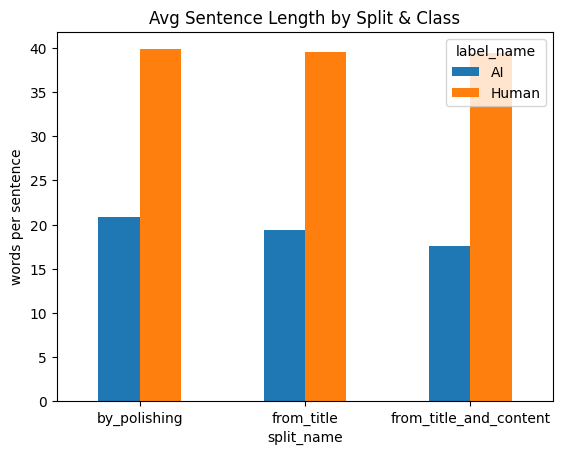

In [ ]:
# Average sentence length by split & class
pivot_len = split_class_stats['avg_sent_len_words'].unstack()
pivot_len.plot(kind='bar', title='Avg Sentence Length by Split & Class', rot=0)
plt.ylabel('words per sentence')
plt.show()

### 3. By Split & Model

In [ ]:
split_stats = df.groupby(['split_name','model_name']).apply(class_stats, include_groups=False)

display(split_stats)

docs  TTR_corpus  avg_word_len  \
split_name             model_name                                     
by_polishing           allam       2851.0      0.0993         5.171   
                       human       2851.0      0.1356         4.957   
                       jais        2851.0      0.1238         5.016   
                       llama       2851.0      0.1080         5.044   
                       openai      2851.0      0.0796         5.201   
from_title             allam       2963.0      0.0602         5.316   
                       human       2963.0      0.1338         4.955   
                       jais        2963.0      0.0751         5.150   
                       llama       2963.0      0.0561         5.119   
                       openai      2963.0      0.0630         5.381   
from_title_and_content allam       2574.0      0.1015         5.250   
                       human       2574.0      0.1420         4.953   
                       jais        2570.0      0.0980         4.964   
                       llama       2574.0      0.0984         5.023   
                       openai      2574.0      0.0929         5.266   

                                   avg_sent_len_words  function_token_ratio  \
split_name             model_name                                             
by_polishing           allam                   18.091                0.6260   
                       human                   39.829                0.6328   
                       jais                    18.109                0.6149   
                       llama                   22.522                0.6243   
                       openai                  23.501                0.6300   
from_title             allam                   17.586                0.6508   
                       human                   39.581                0.6325   
                       jais                    16.373                0.6193   
                       llama                   20.089                0.6418   
                       openai                  22.114                0.6441   
from_title_and_content allam                   15.771                0.6268   
                       human                   39.436                0.6322   
                       jais                    16.565                0.6181   
                       llama                   18.305                0.6311   
                       openai                  19.714                0.6440   

                                   punct_per_1000_chars  avg_sents_per_doc  
split_name             model_name                                           
by_polishing           allam                      17.39              5.279  
                       human                      17.19              2.682  
                       jais                       21.22              3.407  
                       llama                      16.73              4.068  
                       openai                     14.68              6.383  
from_title             allam                      13.09              4.173  
                       human                      17.25              2.698  
                       jais                       19.28              3.477  
                       llama                      14.42              4.599  
                       openai                     12.38              5.228  
from_title_and_content allam                      18.18              5.556  
                       human                      17.23              2.709  
                       jais                       21.12              5.750  
                       llama                      15.72              5.101  
                       openai                     14.28              5.341

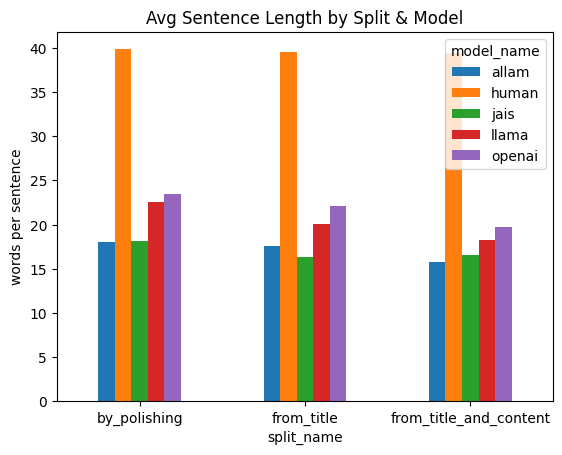

In [ ]:
# Average sentence length by split & model
pivot_len = split_stats['avg_sent_len_words'].unstack()
pivot_len.plot(kind='bar', title='Avg Sentence Length by Split & Model', rot=0)
plt.ylabel('words per sentence')
plt.show()

## EDA Visualization : Word Clouds

Word Clouds per class

In [ ]:
def wordcloud_for(sub_df, title, *, max_docs=None, ax=None):
    """Generate a word cloud for a given sub-dataframe."""
    s = sub_df["text_clean"]

    # Optional unbiased downsampling
    if max_docs is not None and len(s) > max_docs:
        s = s.sample(n=max_docs, random_state=42)

    # Token frequency
    freq = Counter()
    for doc in s:
        freq.update(doc.split())

    wc = ArabicWordCloud(
        width=900,
        height=500,
        background_color="white",
        collocations=False,
    ).generate_from_frequencies(freq)

    if ax is None:
        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title, fontsize=16)
        plt.show()
    else:
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(title, fontsize=12)

### 1. By Class

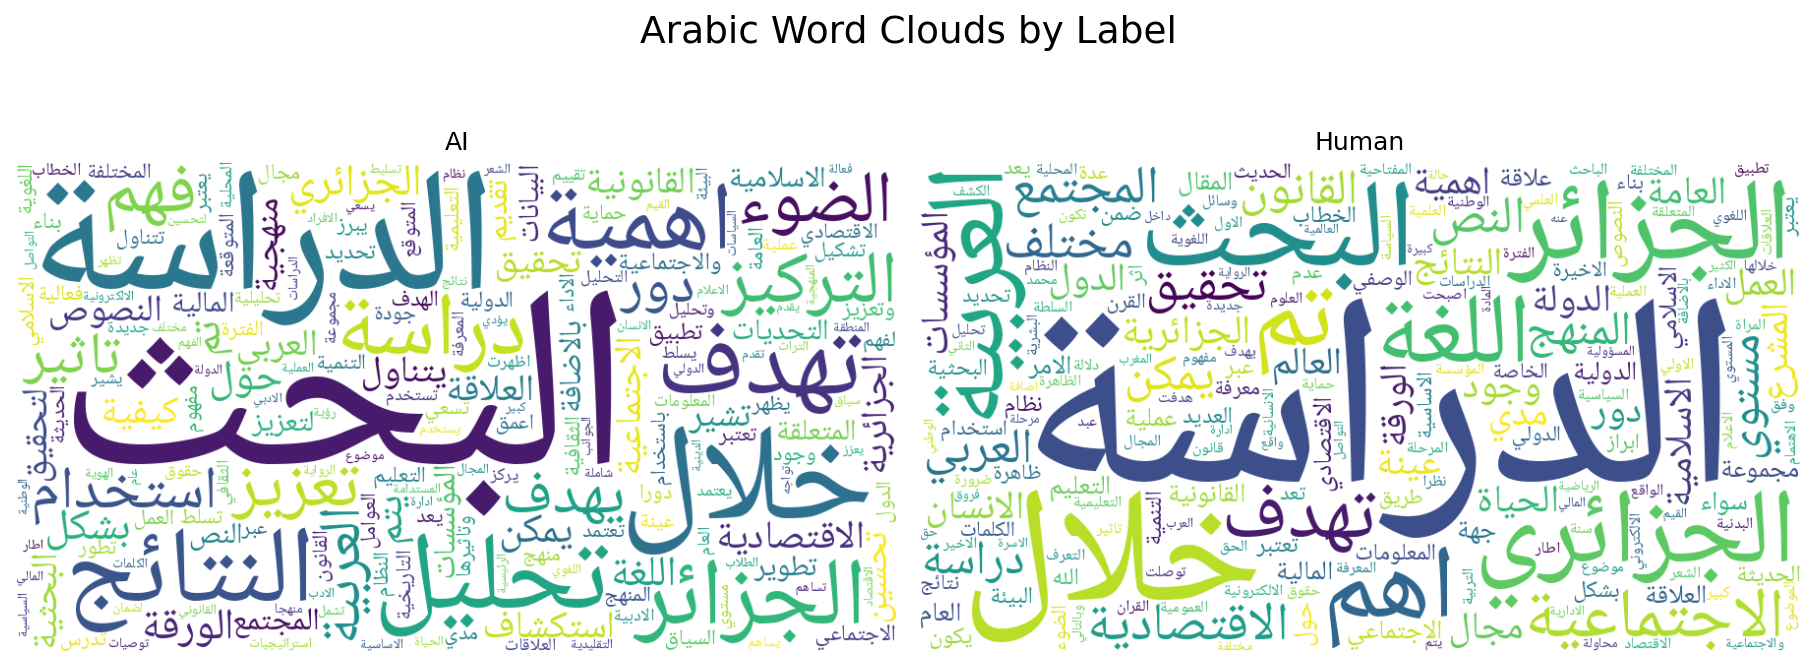

In [ ]:
label_order = sorted(df["label_name"].unique())
n_labels = len(label_order)

fig, axes = plt.subplots(1, n_labels, figsize=(6*n_labels, 5), dpi=150, constrained_layout=True)

for ax, label_name in zip(axes, label_order):
    sub_df = df[df["label_name"] == label_name]
    wordcloud_for(sub_df, label_name, ax=ax)

fig.suptitle("Arabic Word Clouds by Label", fontsize=18)
plt.show()

### 2. By Split & Class

In [ ]:
split_order = sorted(df["split_name"].unique())
label_order = sorted(df["label_name"].unique())

n_rows = len(split_order)
n_cols = len(label_order)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.8*n_rows), dpi=150, constrained_layout=True)

for i, split_name in enumerate(split_order):
    for j, label_name in enumerate(label_order):
        sub_df = df[(df["split_name"] == split_name) & (df["label_name"] == label_name)]
        title = f"{split_name} / {label_name}"
        wordcloud_for(sub_df, title, ax=axes[i][j])

fig.suptitle("Arabic Word Clouds by Split × Label", fontsize=18)
plt.show()


Output hidden; open in https://colab.research.google.com to view.

### 3. By Split & Model

In [ ]:
# Display order
split_order  = sorted(df["split_name"].unique())
model_order  = sorted(df["model_name"].unique())

n_rows = len(split_order)
n_cols = len(model_order)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8*n_cols, 3.6*n_rows), dpi=150, constrained_layout=True)

for i, split_name in enumerate(split_order):
    for j, model_name in enumerate(model_order):
        sub_df = df[(df["split_name"] == split_name) & (df["model_name"] == model_name)]
        title  = f"{split_name} / {model_name}"
        wordcloud_for(sub_df, title, ax=axes[i][j])

# title
fig.suptitle("Arabic Word Clouds by Split × Model", fontsize=18)
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## EDA Visualization : Top n-grams

In [ ]:
def _top_ngrams(text, n=1, top_k=20, min_df=2, max_df=1.0):
    """Return top n-grams (by count)."""
    vec = CountVectorizer(
        analyzer="word",
        ngram_range=(n, n),
        token_pattern=r"(?u)\b[^\W\d_]+\b",  # letters only (Arabic OK)
        min_df=min_df,
        max_df=max_df,
        max_features=50000,
    )
    X = vec.fit_transform(text.astype(str))
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab  = vec.get_feature_names_out()
    return (
        pd.DataFrame({"ngram": vocab, "freq": freqs})
          .nlargest(top_k, "freq")
          .reset_index(drop=True)
    )

# --- utilities to compute & plot -------------------------------------
def compute_by_groups(df, group_cols, *, text_col="text_clean", n_list=(1,2,3),
                       top_k=20, min_df=2, max_df=1.0):
    """
    Returns: dict mapping group_key (tuple) -> {n: DataFrame(ngram,freq)}
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    results = {}
    for key, sub in df.groupby(group_cols):
        key = key if isinstance(key, tuple) else (key,)
        s = sub[text_col]
        results[key] = {n: _top_ngrams(s, n=n, top_k=top_k, min_df=min_df, max_df=max_df)
                        for n in n_list}
    return results


In [ ]:
def plot_ngrams(rows, n_list, results, filter_fn, *,
                row_label_fmt=str, title="", figsize_cell=(5,4), dpi=150,
                row_dim=0):  # <-- which position in the group key defines the row?


    n_rows, n_cols = len(rows), len(n_list)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_cell[0]*n_cols, figsize_cell[1]*n_rows),
                             dpi=dpi, constrained_layout=True)
    if n_rows == 1: axes = [axes]
    if n_cols == 1: axes = [[ax] for ax in axes]

    # shared x-limits per n (column)
    xlims = {}
    for n in n_list:
        mx = 0
        for k in results:
            if filter_fn(k) and not results[k][n].empty:
                mx = max(mx, results[k][n]["freq"].max())
        xlims[n] = mx * 1.05 if mx > 0 else 1

    # column headers
    for j, n in enumerate(n_list):
        axes[0][j].set_title(f"{n}-gram", fontsize=14, pad=10)

    # plot grid
    for i, row_val in enumerate(rows):
        for j, n in enumerate(n_list):
            ax = axes[i][j]

            # find subset for this row & n
            match = None
            for k in results.keys():
                if filter_fn(k) and k[row_dim] == row_val:
                    match = results[k][n]
                    break

            if match is None or match.empty:
                ax.axis("off")
                ax.text(0.5, 0.5, ar_shape("لا توجد بيانات"), ha="center", va="center", fontsize=11)
                continue

            y_labels = match["ngram"].apply(ar_shape).iloc[::-1]
            x_vals   = match["freq"].iloc[::-1]
            bars = ax.barh(y_labels, x_vals)

            # annotate
            for b, v in zip(bars, x_vals):
                ax.text(v + xlims[n]*0.01, b.get_y()+b.get_height()/2,
                        f"{int(v)}", va="center", fontsize=9)

            ax.set_xlim(0, xlims[n])
            ax.set_ylabel("")
            ax.set_xlabel(ar_shape("التكرار") + " / Frequency", fontsize=11)
            if j == 0:
                ax.text(-0.02, 1.02, ar_shape(row_label_fmt(row_val)),
                        transform=ax.transAxes, fontsize=12, fontweight="bold",
                        ha="right", va="bottom")

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.show()


### 1. By Class

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


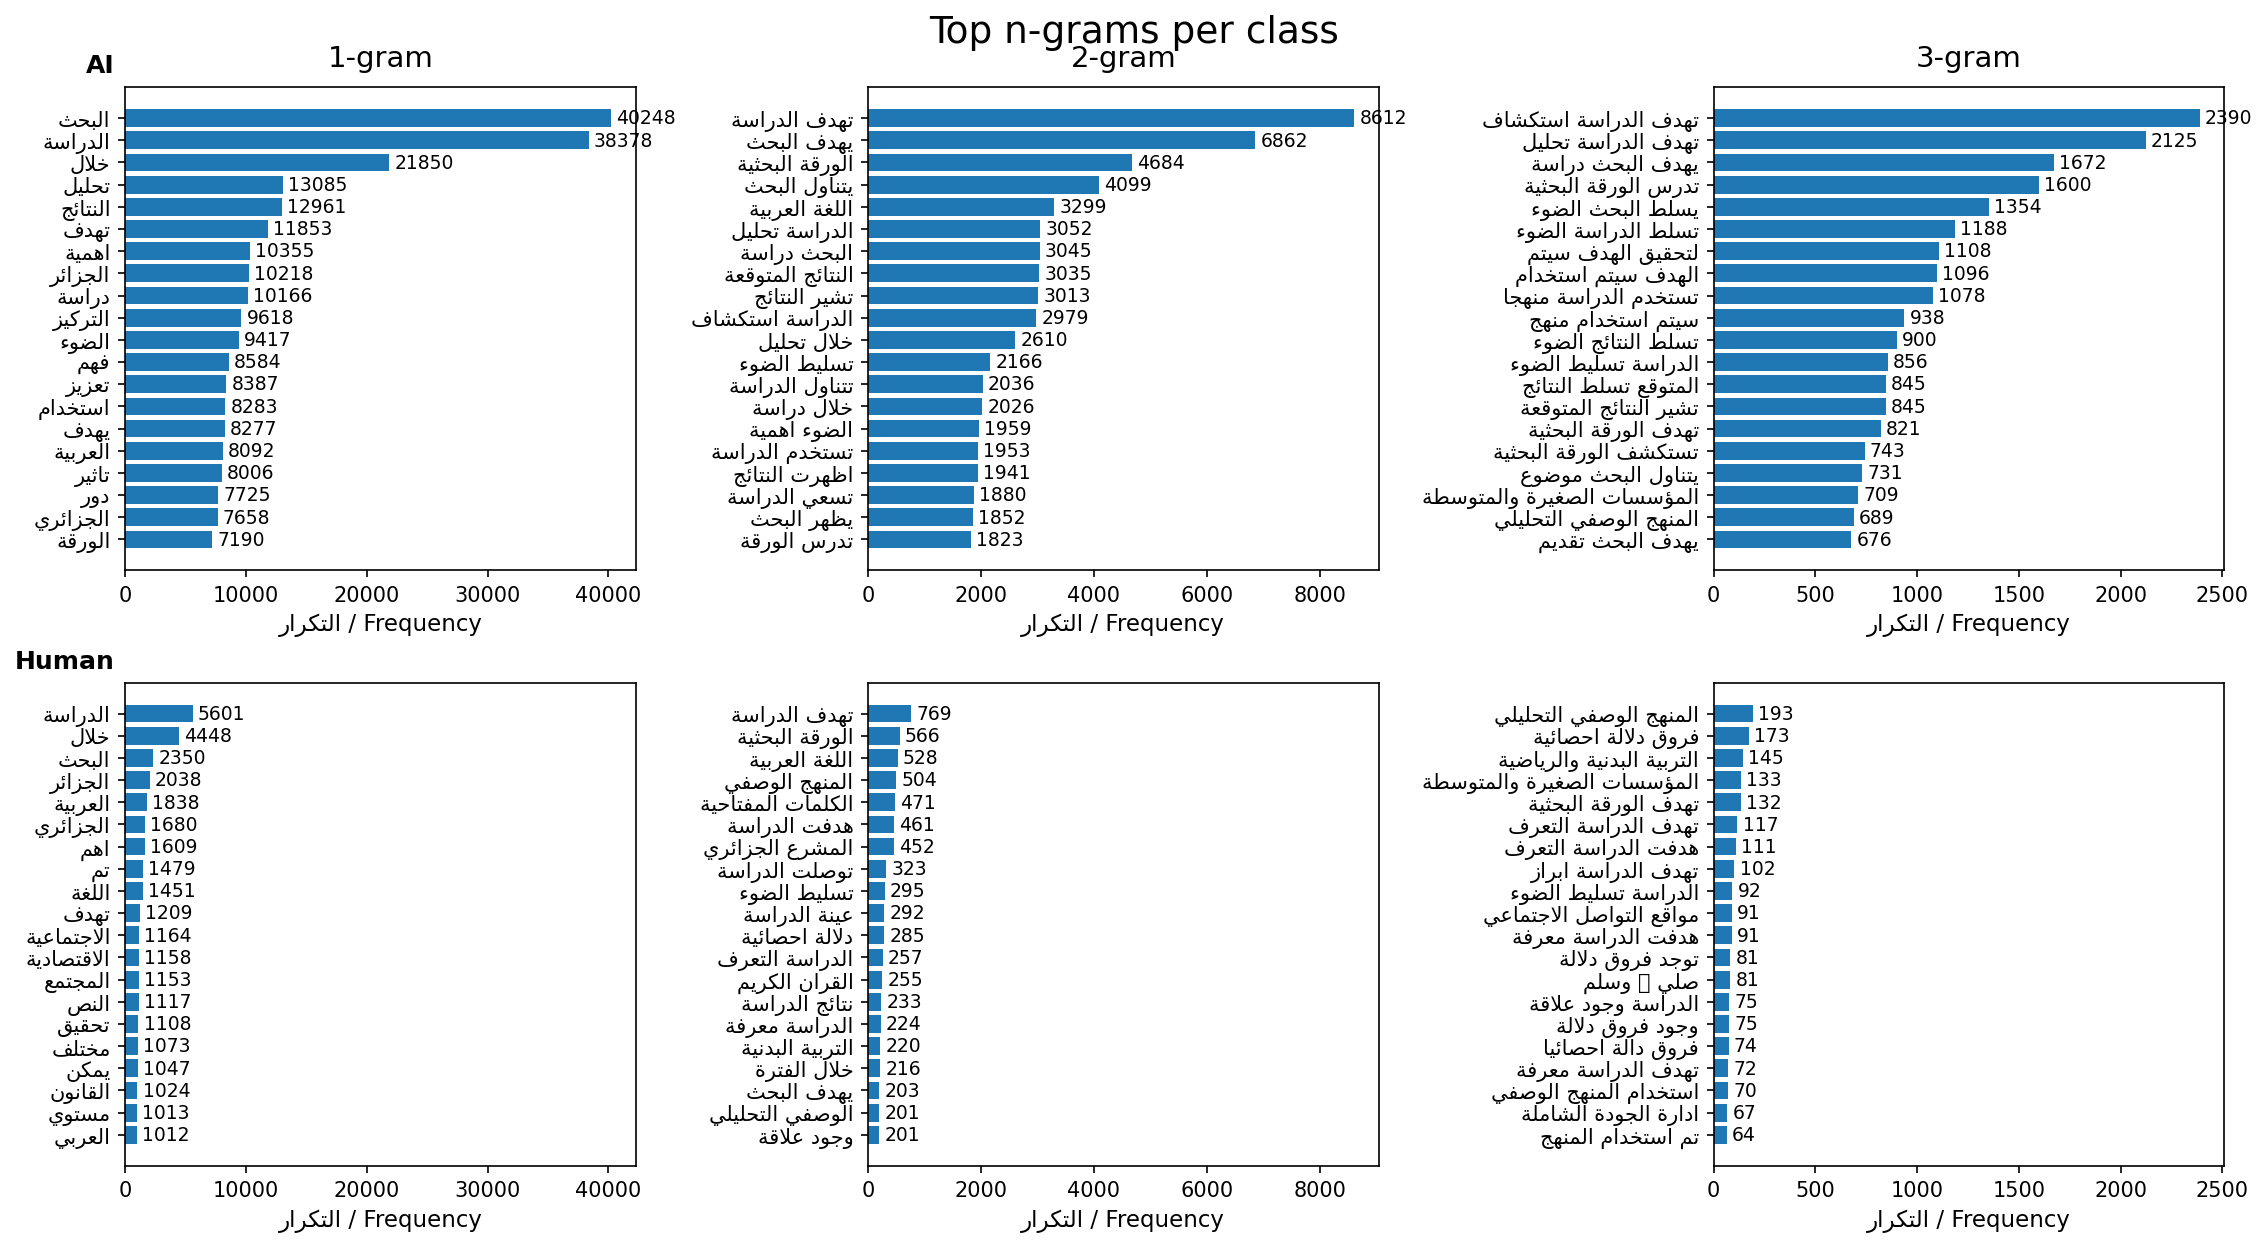

In [ ]:
n_list = (1,2,3)
res_cls = compute_by_groups(df, "label_name", n_list=n_list, top_k=20, min_df=2, max_df=1.0)
rows_cls = sorted({k[0] for k in res_cls})
plot_ngrams(rows=rows_cls, n_list=n_list, results=res_cls,
            filter_fn=lambda k: True, row_label_fmt=lambda v: v,
            title="Top n-grams per class", row_dim=0)   # row is k[0]

### 2. By Split & Class

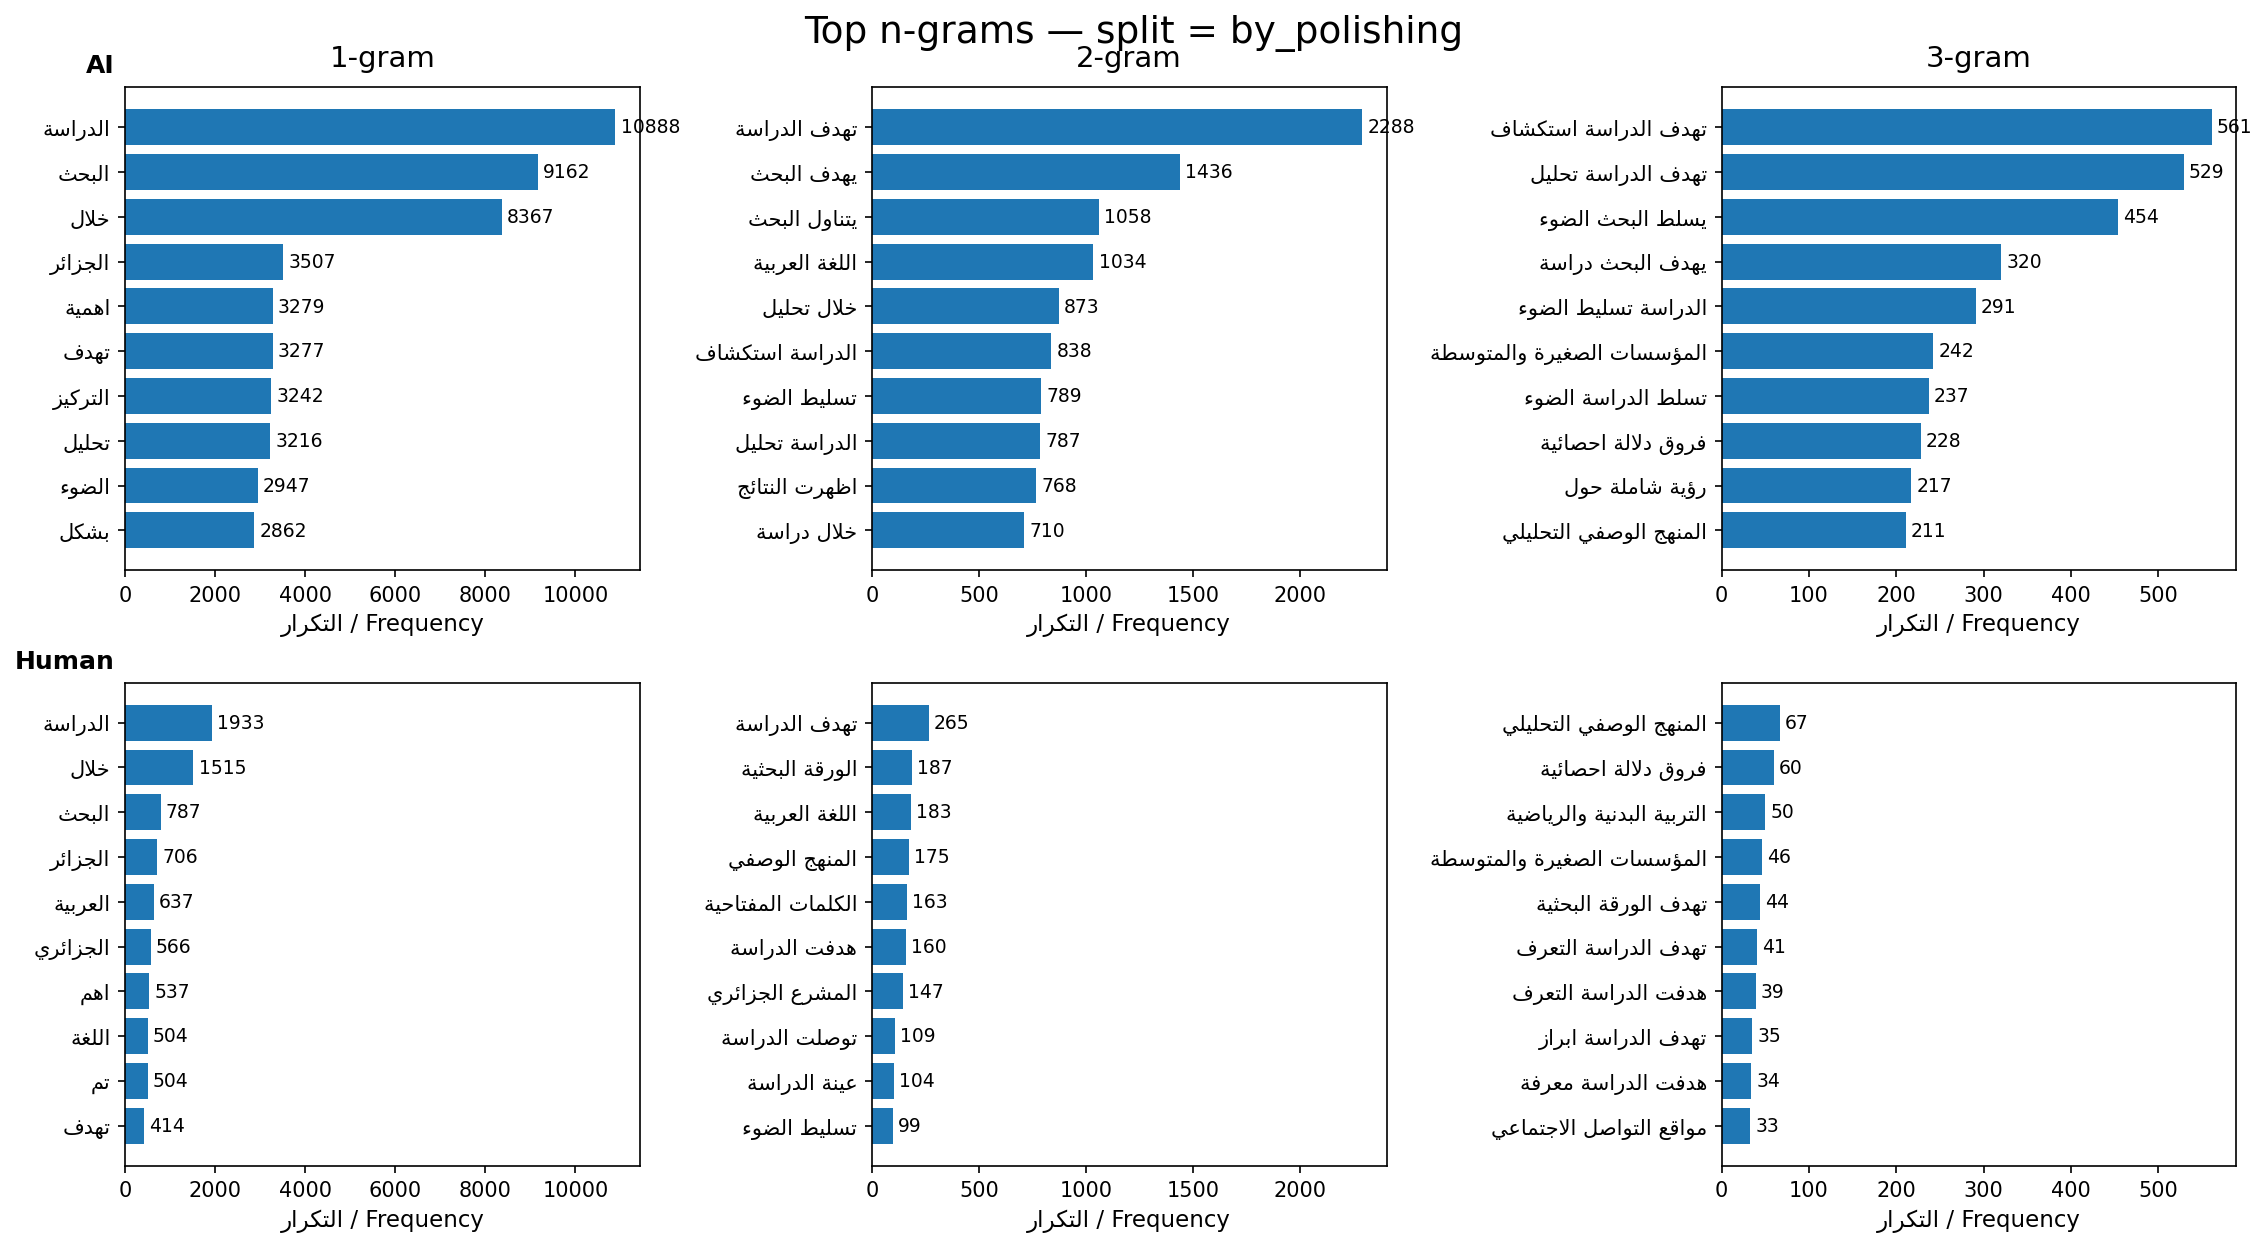

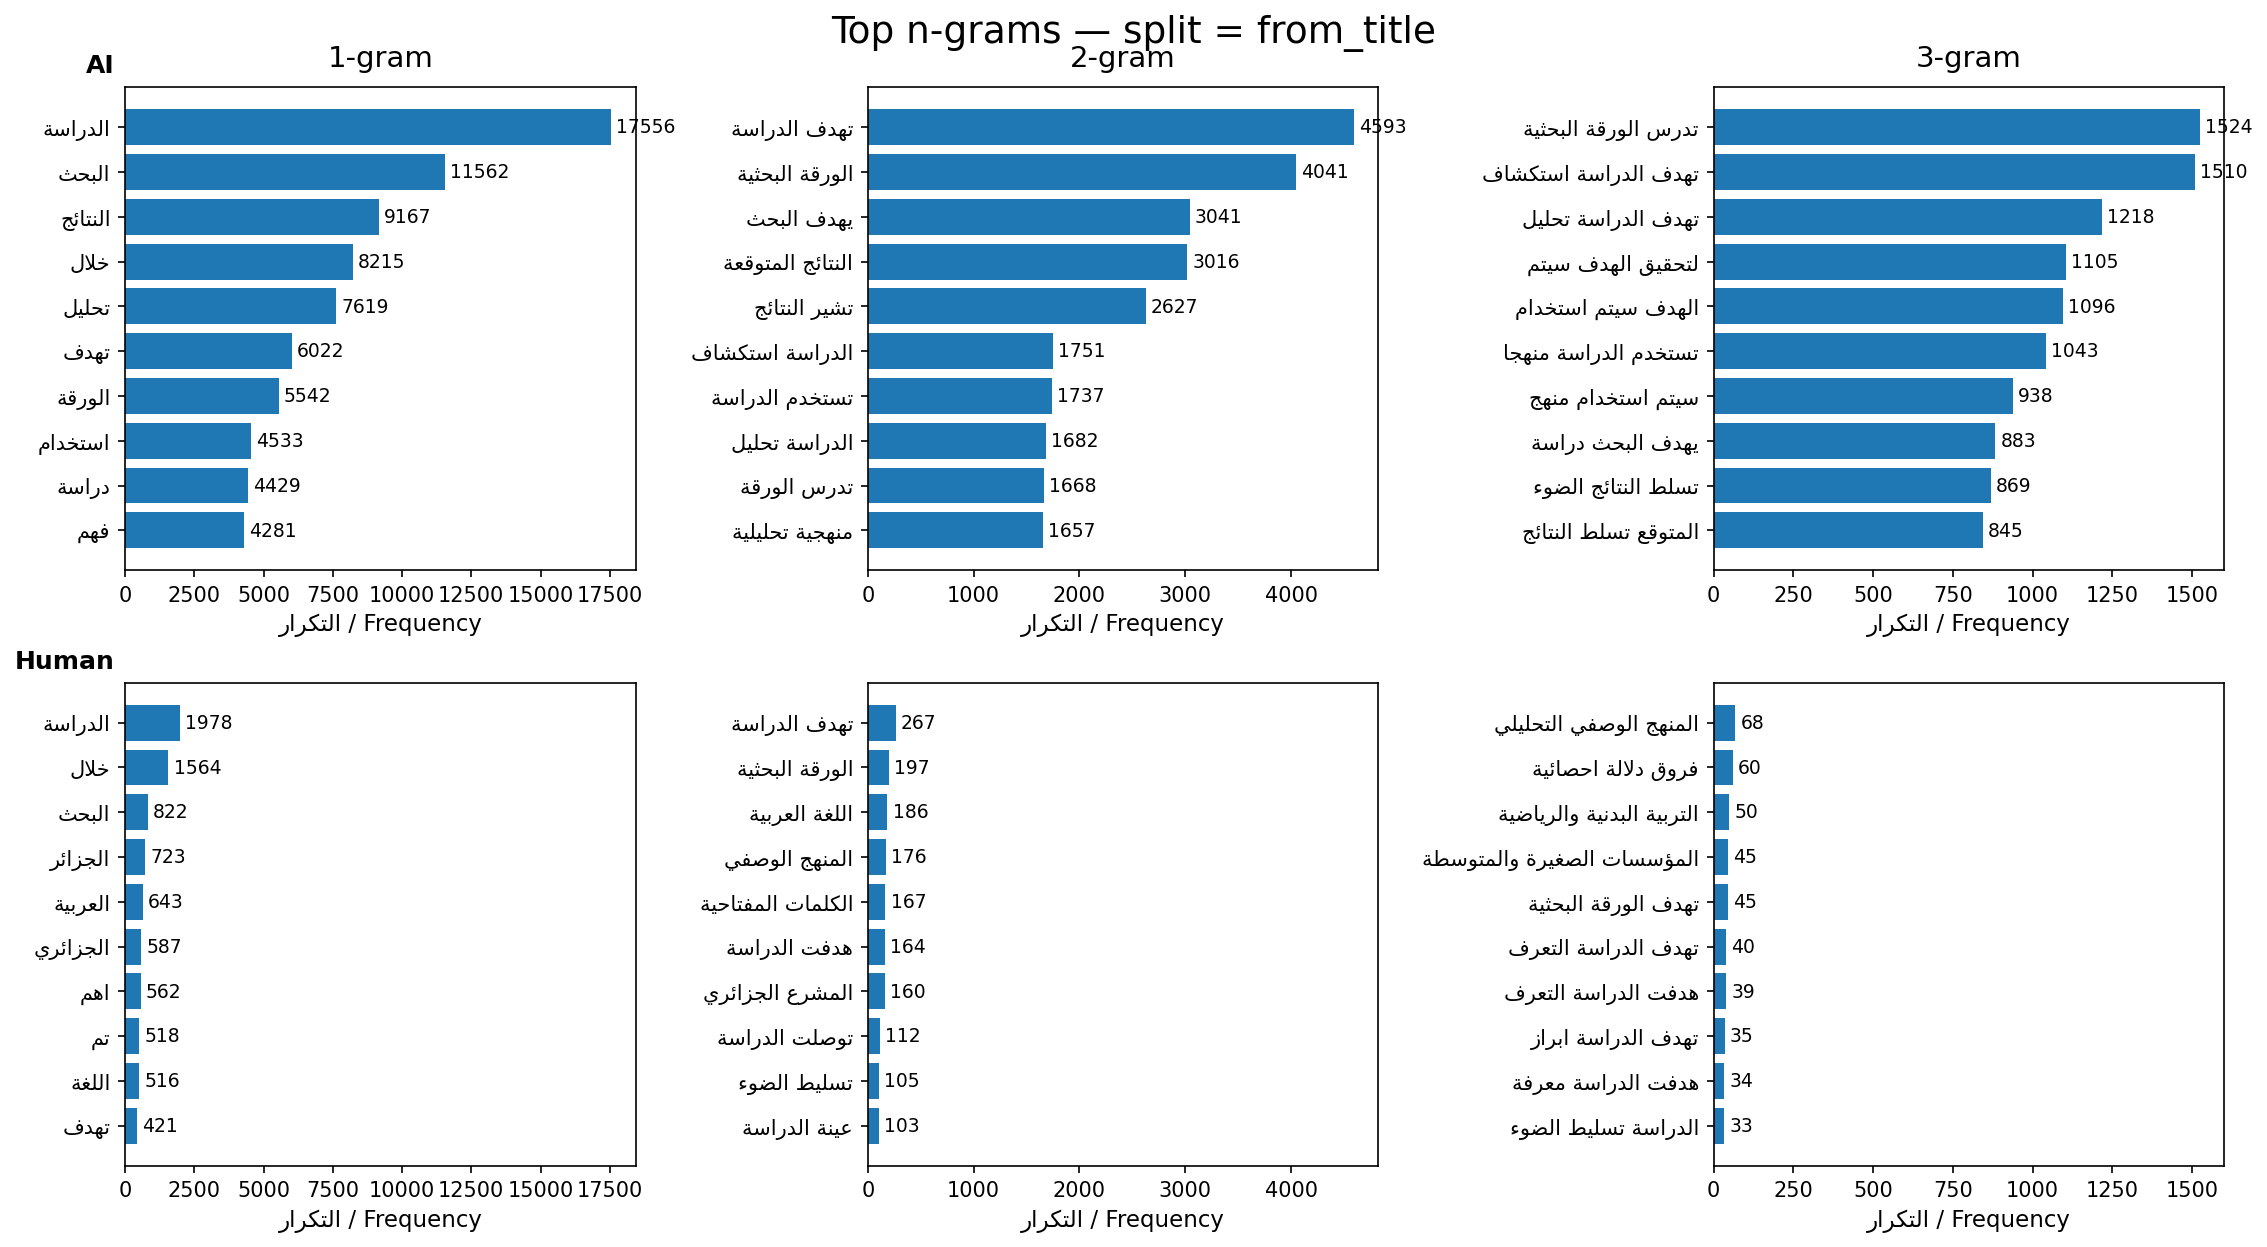

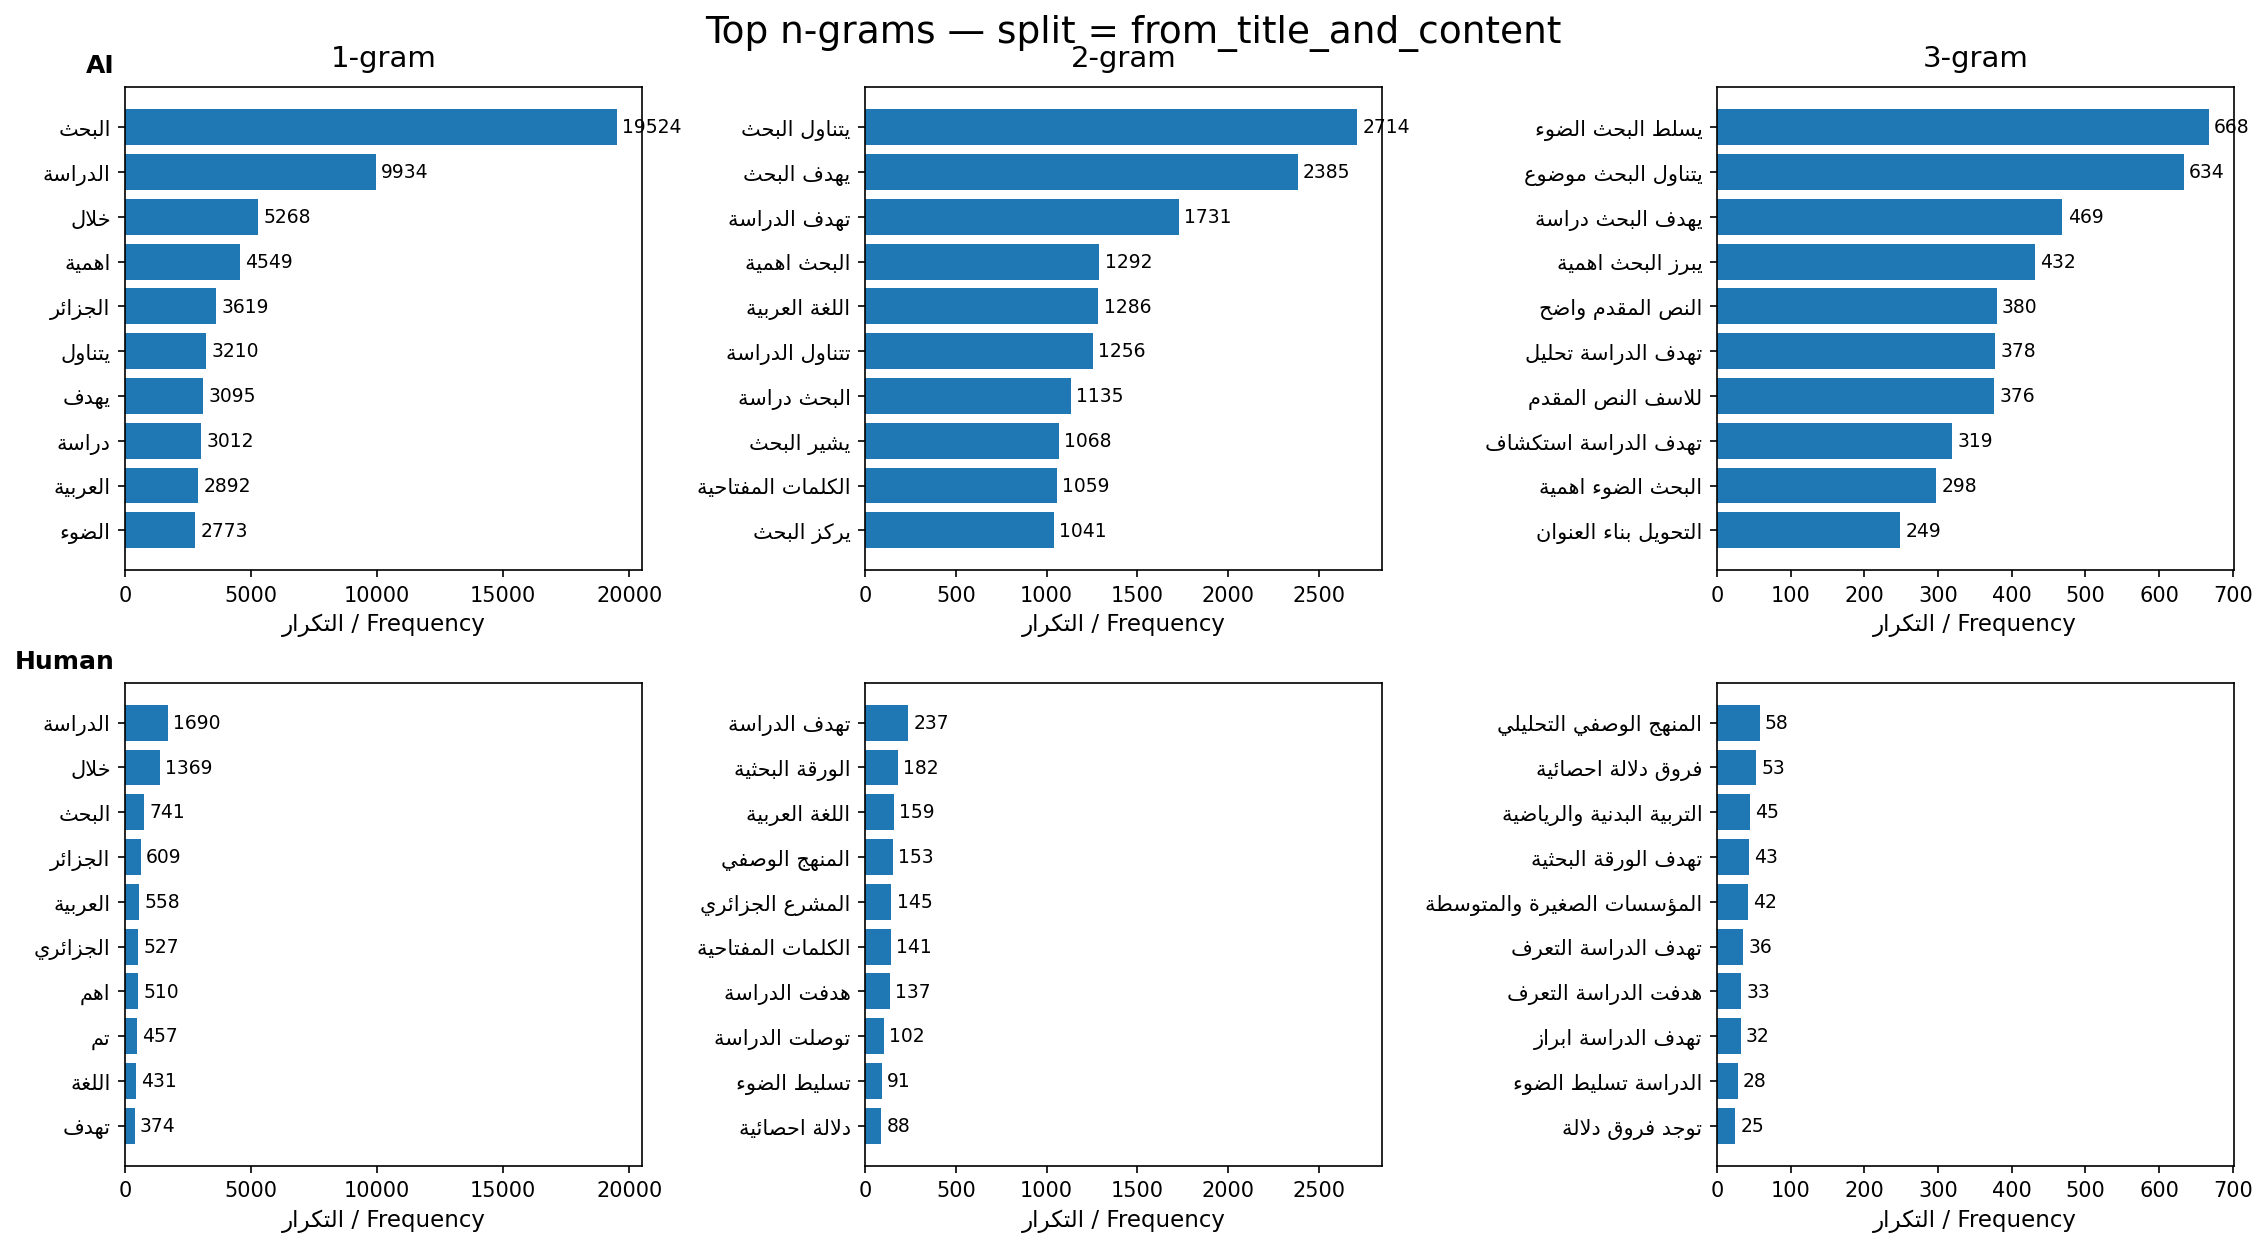

In [ ]:
res_sc = compute_by_groups(df, ["split_name","label_name"], n_list=n_list, top_k=10, min_df=2, max_df=1.0)
splits = sorted({k[0] for k in res_sc})
for split in splits:
    rows_sc = sorted({k[1] for k in res_sc if k[0] == split})  # rows are classes
    plot_ngrams(rows=rows_sc, n_list=n_list, results=res_sc,
                filter_fn=lambda k, s=split: (k[0] == s),
                row_label_fmt=lambda v: v,
                title=f"Top n-grams — split = {split}",
                row_dim=1)  # <-- rows are k[1]


### 3. By Split & Model

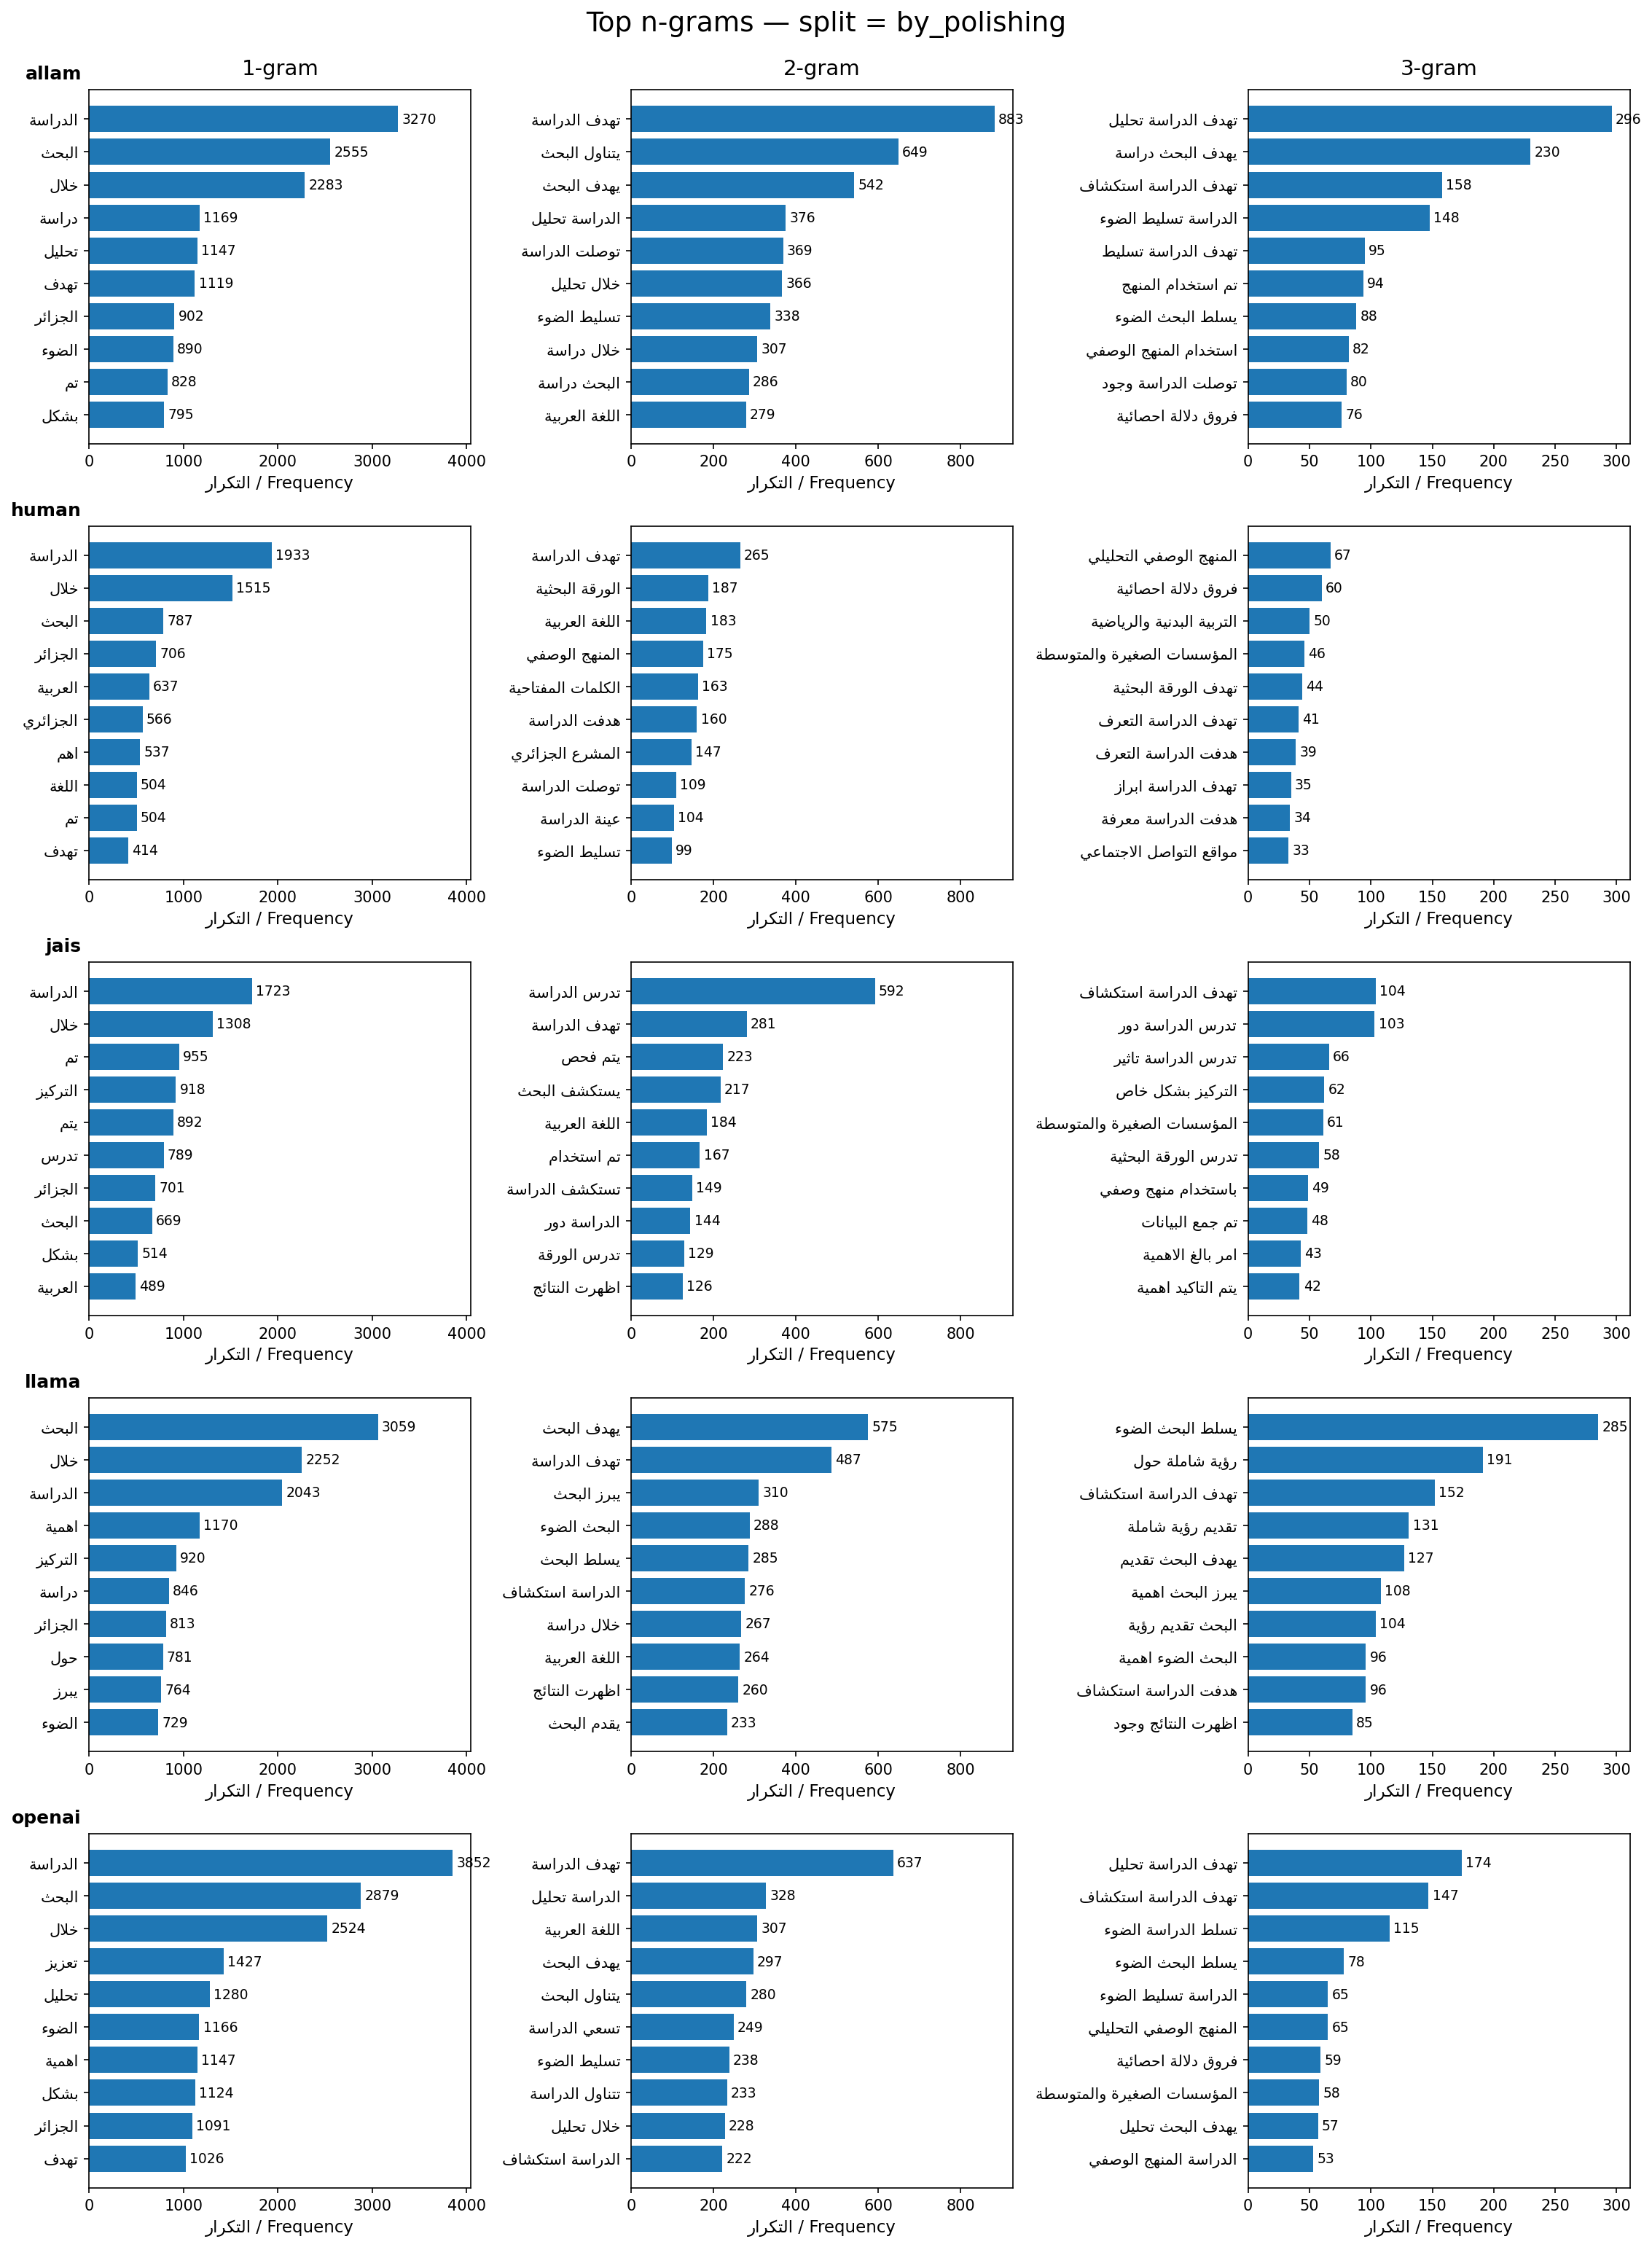

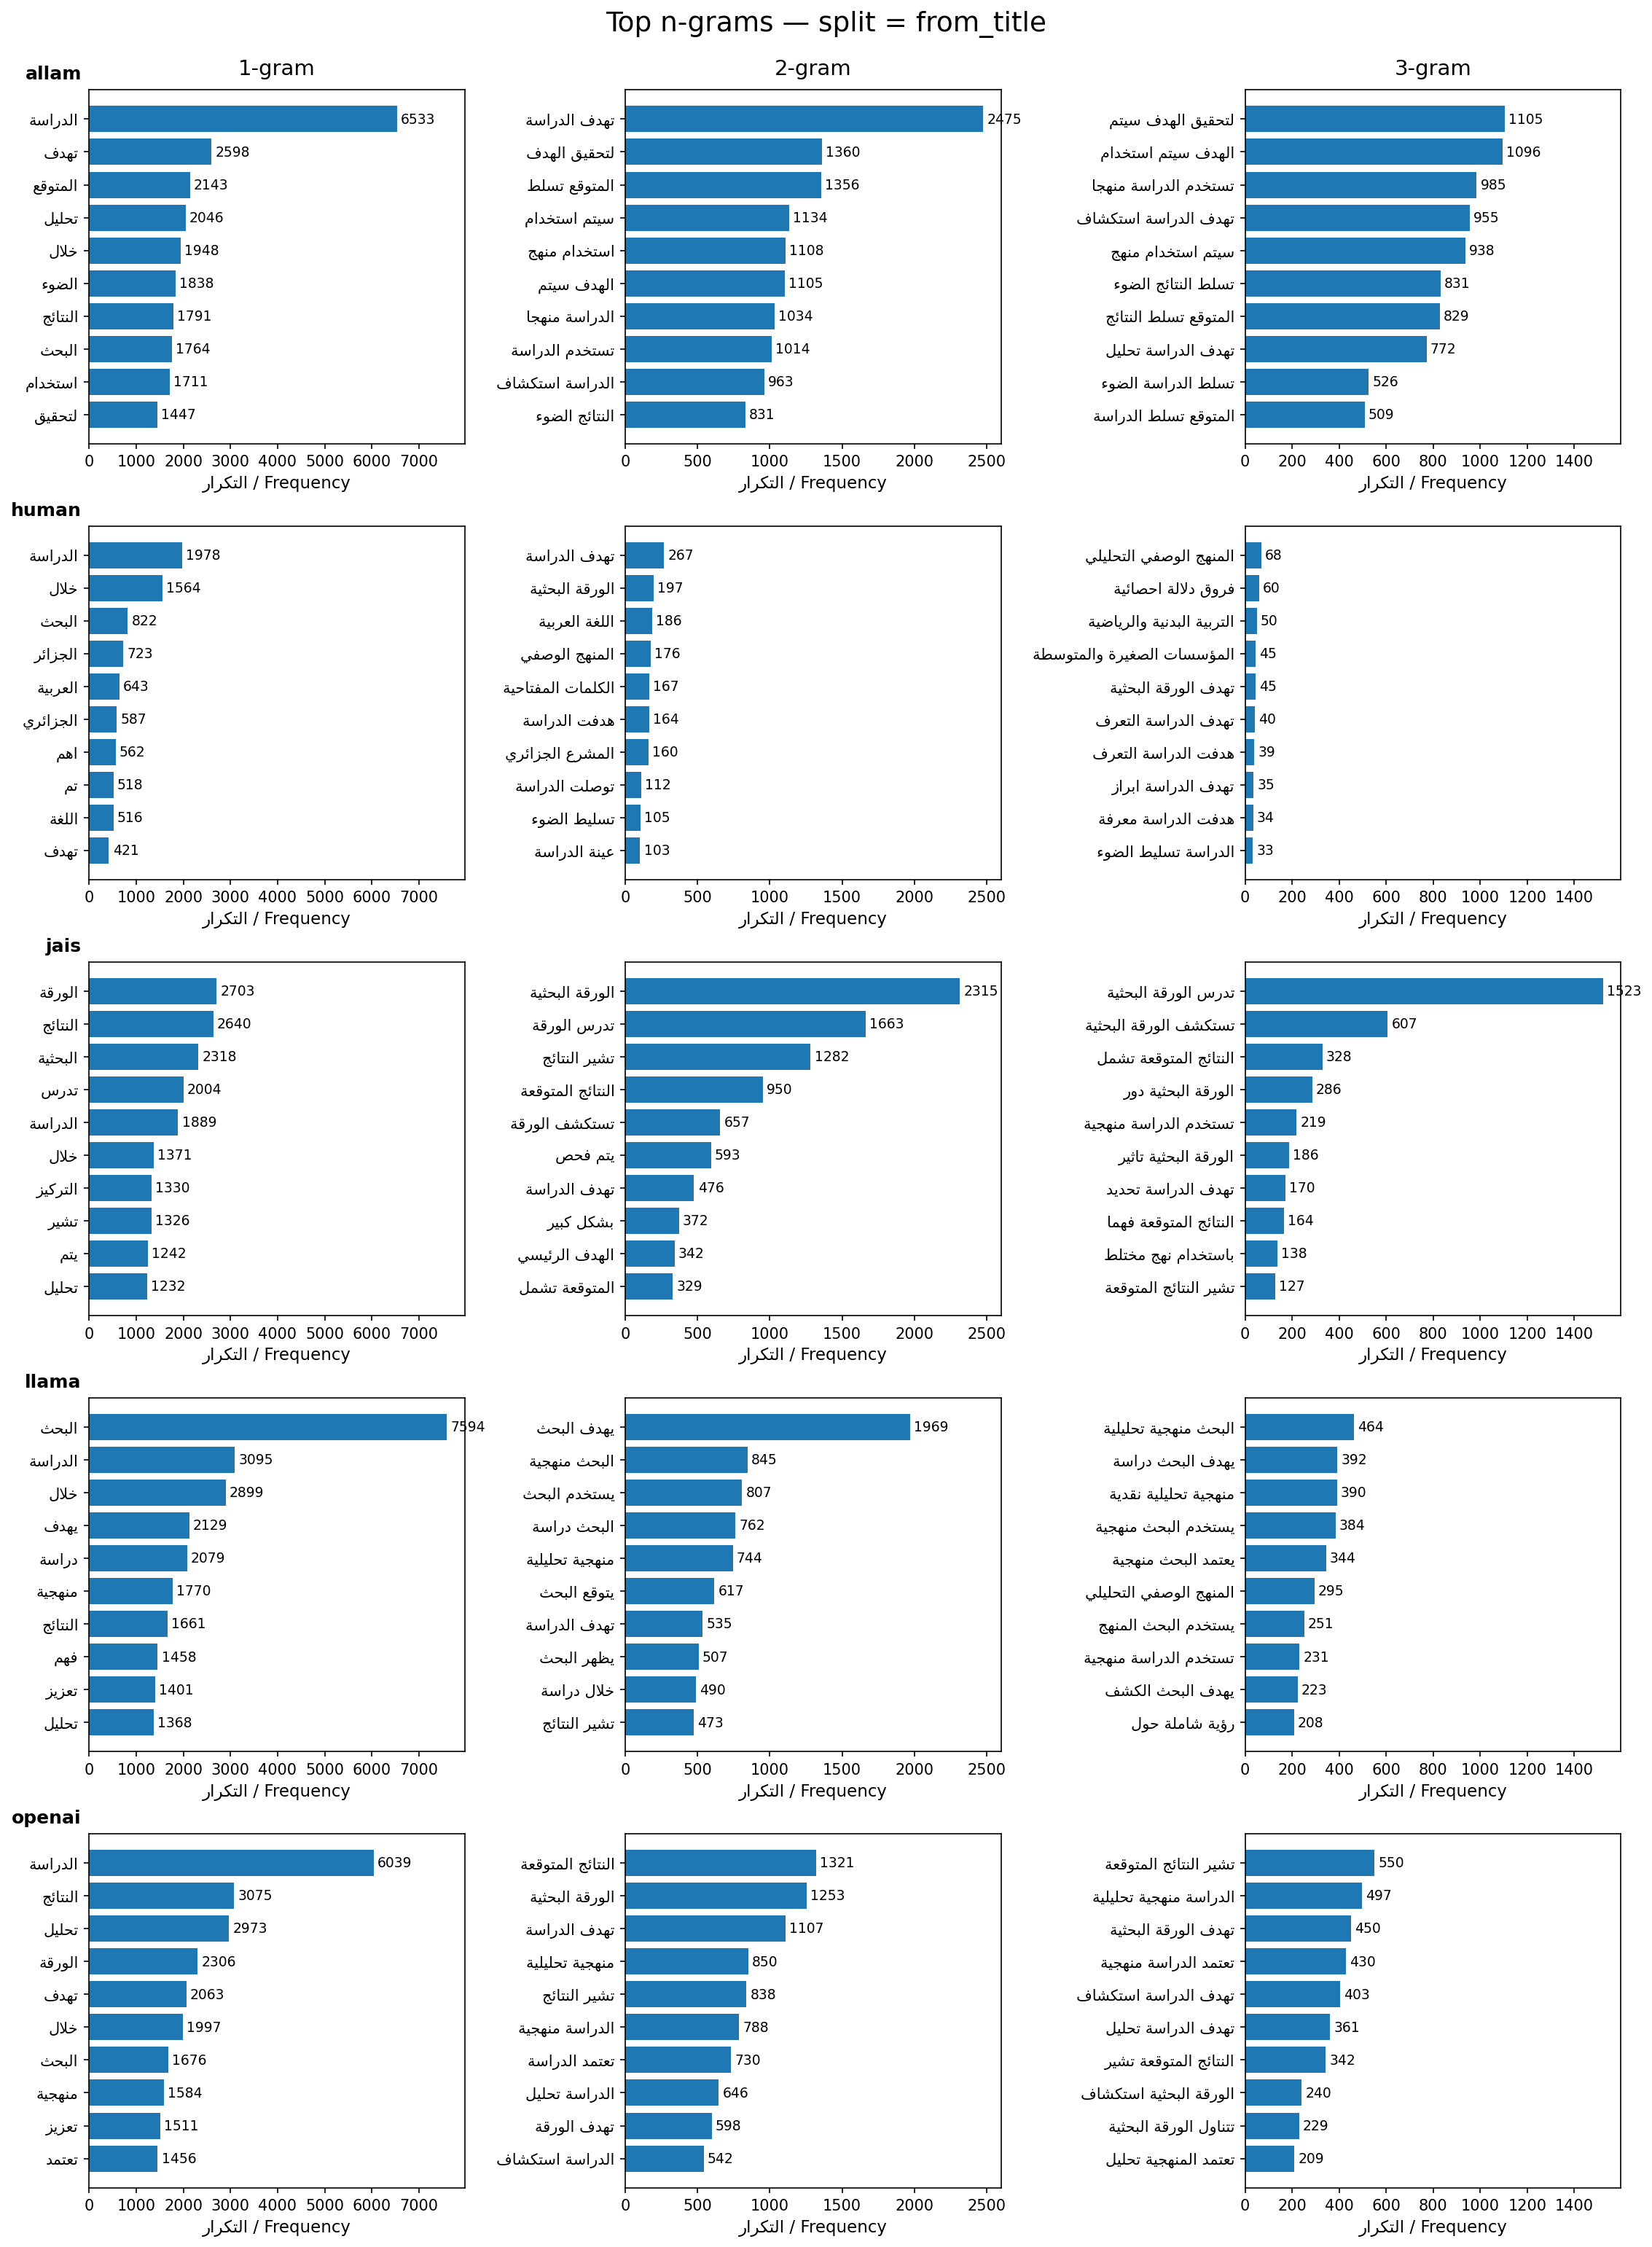

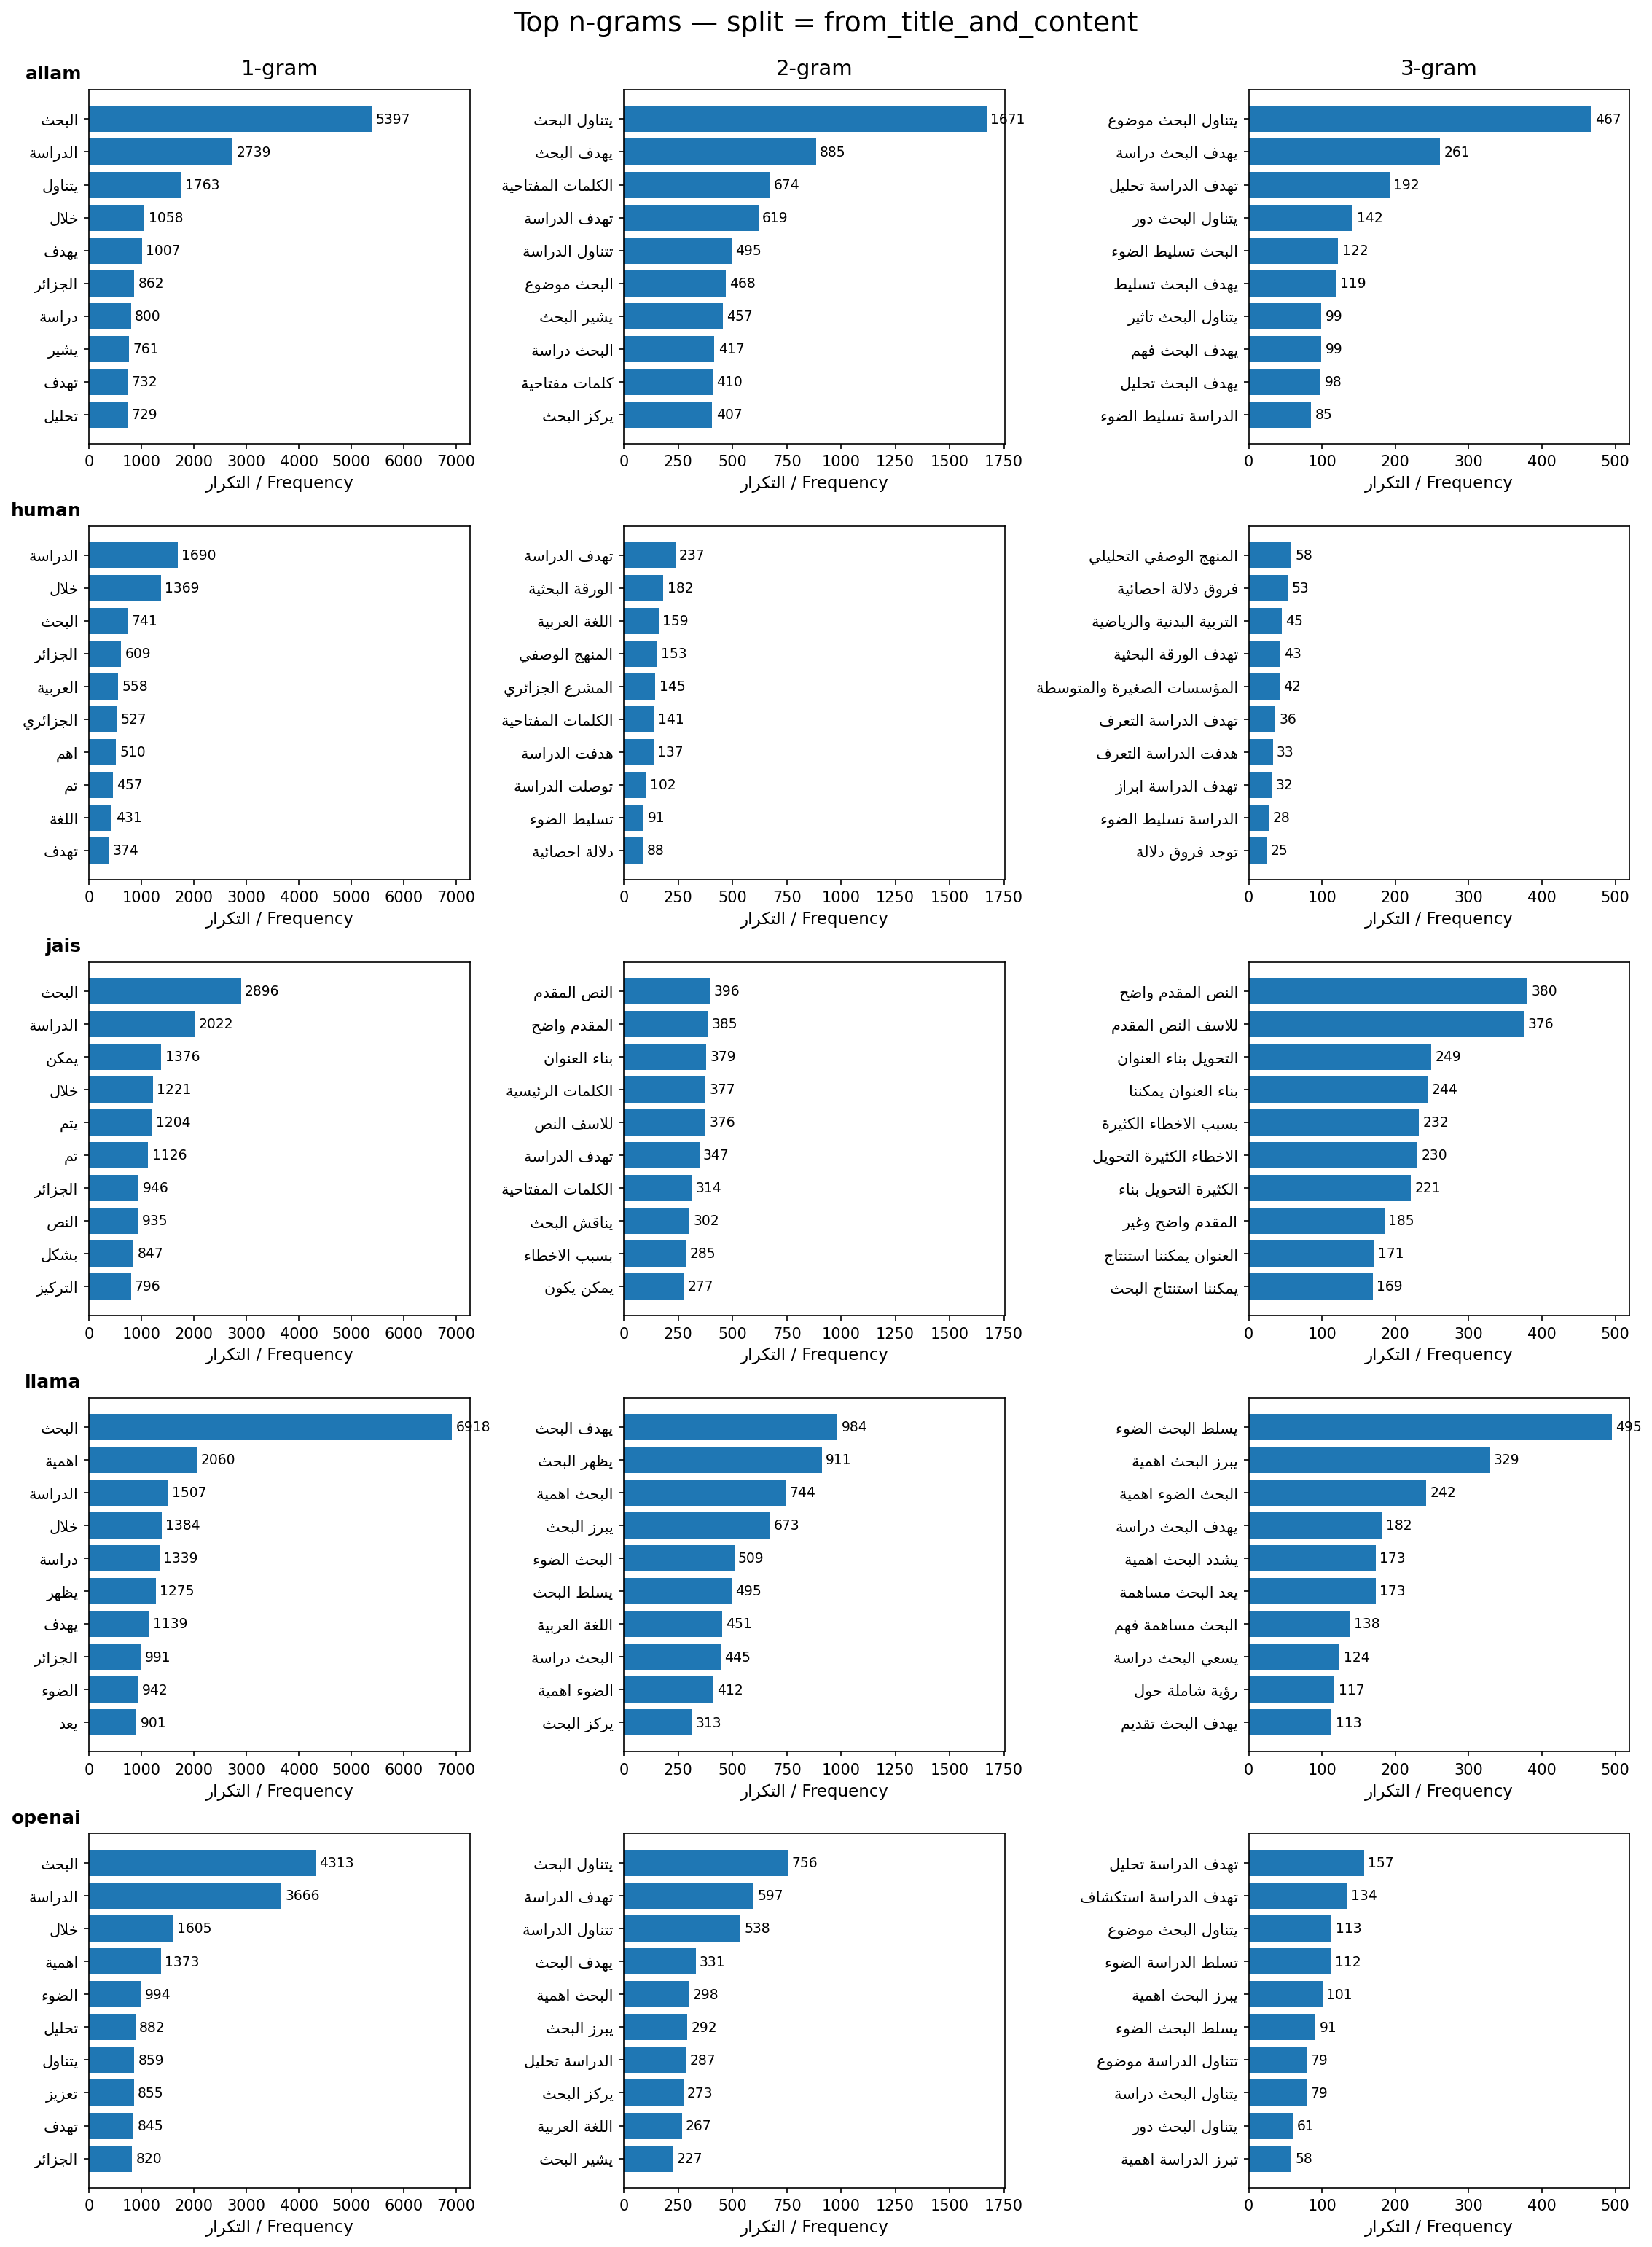

In [ ]:
res_sm = compute_by_groups(df, ["split_name","model_name"], n_list=n_list, top_k=10, min_df=2, max_df=1.0)
splits = sorted({k[0] for k in res_sm})
for split in splits:
    rows_sm = sorted({k[1] for k in res_sm if k[0] == split})  # rows are models
    plot_ngrams(rows=rows_sm, n_list=n_list, results=res_sm,
                filter_fn=lambda k, s=split: (k[0] == s),
                row_label_fmt=lambda v: v,
                title=f"Top n-grams — split = {split}",
                row_dim=1)  # <-- rows are k[1]
